In [1]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
SAMPLING_RATE = 3000

# Load ECG dataset
ecg_signal = nk.data(dataset=f"ecg_{SAMPLING_RATE}hz")

print(ecg_signal[:10])

[-0.3894043  -0.38192749 -0.37811279 -0.37475586 -0.36743164 -0.36270142
 -0.35888672 -0.35049439 -0.34637451 -0.34286499]


In [3]:
# Detect R peaks
_, rpeaks = nk.ecg_peaks(ecg_signal, sampling_rate=SAMPLING_RATE)

print(rpeaks.keys()) 

dict_keys(['method_peaks', 'method_fixpeaks', 'ECG_R_Peaks', 'sampling_rate'])


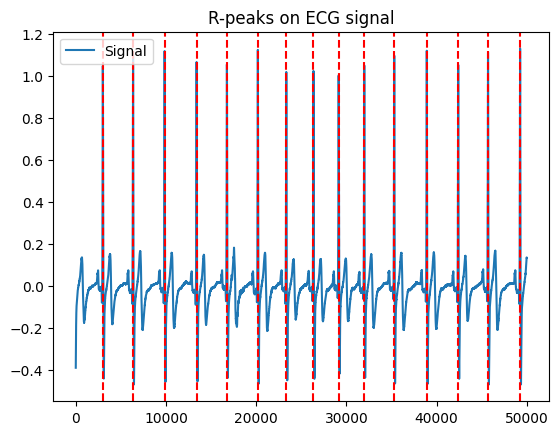

In [4]:
# Plot ECG signal with detected R peaks
nk.events_plot(rpeaks["ECG_R_Peaks"], ecg_signal)
plt.title("R-peaks on ECG signal")
plt.show()

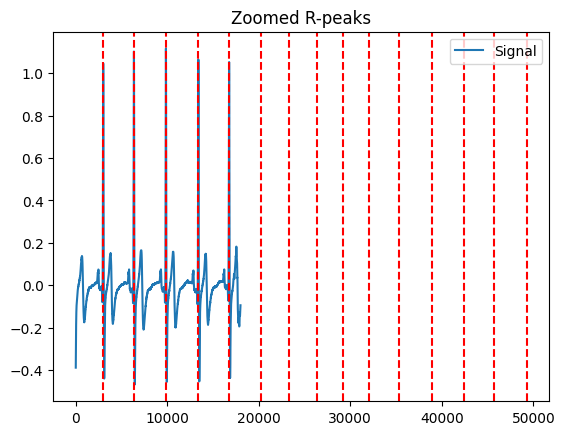

In [ ]:
# Zoom into into the first few peaks to see them more clearly
nk.events_plot(
    rpeaks["ECG_R_Peaks"][:5],
    ecg_signal[:6 * SAMPLING_RATE]
)
plt.title("Zoomed R-peaks")
plt.show()

In [6]:
#Delineate ECG waves (P, Q, S, T)
signals, waves = nk.ecg_delineate(
    ecg_signal,
    rpeaks,
    sampling_rate=SAMPLING_RATE,
    method="dwt" 
)

print(waves.keys())

dict_keys(['ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets'])


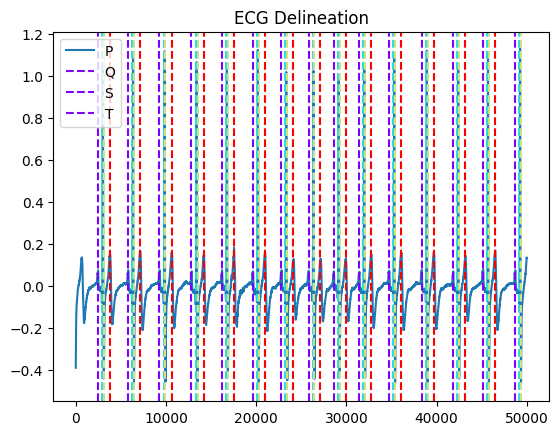

In [8]:
#Visualize the detected waves
nk.events_plot(
    [
        waves["ECG_P_Peaks"],
        waves["ECG_Q_Peaks"],
        waves["ECG_S_Peaks"],
        waves["ECG_T_Peaks"],
    ],
    ecg_signal
)

plt.legend(["P", "Q","S", "T"])
plt.title("ECG Delineation")
plt.show()